# Lesson 8.6: What Is Self-RAG and Corrective RAG?

**Companion notebook for Lesson 8.6**

---

| Section | What you will build |
|---|---|
| 1. Three Failure Modes | Measure each failure on a real corpus — not just describe it |
| 2. Gate 1: Should I Retrieve? | `NeedsRetrievalClassifier` — skip the vector DB when unnecessary |
| 3. Gate 2: Relevance Evaluator | Score retrieved docs; route to correct / ambiguous / incorrect |
| 4. Knowledge Refinement Strips | CRAG-style sentence-level scoring to remove noise within docs |
| 5. Gate 3: Self-Supported Check | Verify the answer is grounded in context before returning it |
| 6. Full CRAG Pipeline | Three confidence tracks + fallback path in one function |
| 7. Self-RAG Concepts | Reflection tokens demo — what the model reasons about internally |
| 8. Adaptive RAG Evaluation | Vanilla RAG vs. Adaptive RAG on 10 queries — score comparison |
| 9. Claude API | Real LLM for all four gates |

**Required:** `sentence-transformers`, `numpy`, `matplotlib`  
**Optional (Section 9):** `anthropic`

In [ ]:
# Uncomment to install
# !pip install sentence-transformers numpy matplotlib
# !pip install anthropic   # optional — Section 9

In [1]:
%matplotlib inline

import os
import re
import warnings

os.environ['OMP_NUM_THREADS']         = '1'
os.environ['MKL_NUM_THREADS']         = '1'
os.environ['HF_HUB_DOWNLOAD_TIMEOUT'] = '60'
os.environ['TOKENIZERS_PARALLELISM']  = 'false'
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size']      = 11
plt.rcParams['axes.grid']      = True
plt.rcParams['grid.alpha']     = 0.3

def show_plot():
    plt.tight_layout()
    plt.show()

print('Imports ready.')

Imports ready.


---
## 1. The Three Failure Modes of Vanilla RAG

Vanilla RAG makes one assumption: **retrieval is always helpful.** It retrieves whether or not the question needs external knowledge, uses whatever it retrieves whether or not it is relevant, and generates whether or not the output is grounded.

```
┌────────────────────────────────────────────────────────────────────────┐
│                THREE WAYS VANILLA RAG FAILS                            │
└────────────────────────────────────────────────────────────────────────┘

  Failure 1: Retrieval when none is needed
  Query: "Hi, can you help me?"
  Action: retrieves 5 random chunks → LLM mentions refund policies in a greeting

  Failure 2: Retrieved docs are irrelevant
  Query: "What is the refund policy for hardware?"
  Action: retrieves software refund docs (closest in vector space)
          → LLM writes a confident answer based on the WRONG policy

  Failure 3: LLM hallucinates beyond what is supported
  Query: "What is the warranty period for the X1 device?"
  Action: retrieves X1 specs doc (relevant topic, no warranty info)
          → LLM invents a plausible-sounding warranty period not in the docs

  Fix: add a decision layer. Teach the system to reason about retrieval itself.
```

In [2]:
from sentence_transformers import SentenceTransformer, util

print('Loading all-MiniLM-L6-v2...')
embedder = SentenceTransformer('all-MiniLM-L6-v2', device='cpu')

# ── TechCo product support corpus ────────────────────────────────────────────
CORPUS = [
    {'id': 'doc0', 'title': 'Hardware Refund Policy',
     'text': (
         'Hardware products can be returned within 30 days of purchase for a full refund. '
         'The product must be in original packaging with no signs of physical damage. '
         'Refunds are processed within 5 to 7 business days after receipt. '
         'Contact hardware-returns@techco.com to initiate a hardware return.'
     )},
    {'id': 'doc1', 'title': 'Software Refund Policy',
     'text': (
         'Software licenses are non-refundable once activated. '
         'Exceptions apply if the software is defective or misrepresented. '
         'Refund requests must be submitted within 14 days of purchase. '
         'Contact billing@techco.com for software refund inquiries.'
     )},
    {'id': 'doc2', 'title': 'X1 Device Specifications',
     'text': (
         'The TechCo X1 is a compact professional workstation. '
         'Processor: Intel Core i7-13700, RAM: 32GB DDR5, Storage: 1TB NVMe SSD. '
         'Dimensions: 180mm x 185mm x 39mm, Weight: 1.3 kg. '
         'The X1 supports up to three external displays via Thunderbolt 4.'
     )},
    {'id': 'doc3', 'title': 'X2 Device Specifications',
     'text': (
         'The TechCo X2 is a high-performance desktop workstation. '
         'Processor: Intel Core i9-13900K, RAM: 64GB DDR5, Storage: 2TB NVMe SSD. '
         'Dimensions: 345mm x 376mm x 175mm, Weight: 12.5 kg. '
         'The X2 supports up to eight displays and includes a dedicated GPU slot.'
     )},
    {'id': 'doc4', 'title': 'Warranty Terms',
     'text': (
         'All TechCo hardware products are covered by a standard one-year limited warranty. '
         'The warranty covers manufacturing defects and component failures under normal use. '
         'Physical damage, liquid damage, and unauthorized modifications are not covered. '
         'Extended warranty plans of two or three years are available for purchase separately.'
     )},
    {'id': 'doc5', 'title': 'Shipping Policy',
     'text': (
         'Standard shipping within the continental US costs $9.99 and takes 5 to 7 business days. '
         'Expedited shipping costs $24.99 and arrives within 2 to 3 business days. '
         'Orders over $500 qualify for free standard shipping. '
         'International shipping rates vary by destination country.'
     )},
    {'id': 'doc6', 'title': 'Installation Guide',
     'text': (
         'TechCo devices require the TechCo Setup Assistant for initial configuration. '
         'Download the Setup Assistant from techco.com/support before connecting the device. '
         'Installation typically takes 15 to 30 minutes on a stable internet connection. '
         'Detailed instructions are included in the printed Quick Start Guide.'
     )},
    {'id': 'doc7', 'title': 'Billing FAQ',
     'text': (
         'Subscriptions are billed monthly on the anniversary of your signup date. '
         'Annual plans are billed once per year and include a 20 percent discount. '
         'Accepted payment methods: Visa, Mastercard, American Express, and ACH transfer. '
         'Invoices are available in the billing portal at my.techco.com.'
     )},
]

corpus_texts  = [d['text'] for d in CORPUS]
corpus_embeds = embedder.encode(corpus_texts, convert_to_tensor=True, show_progress_bar=False)

def retrieve(query: str, top_k: int = 3):
    q_emb   = embedder.encode(query, convert_to_tensor=True, show_progress_bar=False)
    scores  = util.cos_sim(q_emb, corpus_embeds)[0].cpu().numpy()
    indices = np.argsort(scores)[::-1][:top_k]
    return [(CORPUS[i], float(scores[i])) for i in indices]

print(f'Corpus: {len(CORPUS)} docs. Retriever ready.')

Loading all-MiniLM-L6-v2...
Corpus: 8 docs. Retriever ready.


In [4]:
class MockRAGLLM:
    '''
    Simulates LLM behavior in three retrieval scenarios:
    1. Direct (no context): greetings and math answered cleanly
    2. Good context: correct extraction from relevant docs
    3. Partial/wrong context: hallucination to fill gaps
    '''

    def direct_answer(self, query: str) -> str:
        q = query.lower()
        if any(g in q for g in ['hi', 'hello', 'hey', 'can you help', 'what can you']):
            return 'Hello! I am here to help with your TechCo product questions.'
        if '2 + 2' in q or 'math' in q or 'calculate' in q:
            return '2 + 2 = 4.'
        if 'joke' in q or 'funny' in q:
            return 'Why do programmers prefer dark mode? Because light attracts bugs!'
        return 'I can help with that from my general knowledge.'

    def generate(self, query: str, context: str) -> str:
        q   = query.lower()
        ctx = context.lower()

        # Failure mode 1: greeting with irrelevant context
        if any(g in q for g in ['hi', 'hello', 'hey', 'can you help']):
            snippet = context[:80] if context else ''
            return f'Hello! Based on our documentation: {snippet}... How can I assist you?'

        # Failure mode 2: hardware refund with wrong (software) docs
        if 'hardware' in q and 'refund' in q:
            if '30 days' in ctx:
                return 'Hardware products can be returned within 30 days for a full refund.'
            if 'non-refundable' in ctx and '30 days' not in ctx:
                return ('Our refund policy states that products are non-refundable once activated. '
                        'For hardware, similar restrictions may apply within 14 days.')

        # Failure mode 3: warranty query with X1 specs (no warranty info) → hallucinate
        if 'warranty' in q:
            if 'one-year' in ctx:
                return 'TechCo hardware products are covered by a one-year limited warranty for manufacturing defects.'
            if ('x1' in ctx or 'x2' in ctx) and 'warranty' not in ctx:
                # Context mentions the device but has no warranty info — hallucinate
                return 'The TechCo X1 comes with a comprehensive 3-year warranty covering all hardware defects and accidental damage.'

        # Correct answers from good context
        if 'shipping' in q and '$9.99' in ctx:
            return 'Standard shipping costs $9.99 (5 to 7 days). Free for orders over $500. Expedited is $24.99.'
        if ('billing' in q or 'invoice' in q) and 'monthly' in ctx:
            return 'Subscriptions are billed monthly. Annual plans include a 20 percent discount.'
        if 'install' in q and 'setup assistant' in ctx:
            return 'Download the TechCo Setup Assistant from techco.com/support. Installation takes 15 to 30 minutes.'

        return f'Based on our documentation: {context[:200]}'


llm = MockRAGLLM()
print('MockRAGLLM ready.')

MockRAGLLM ready.


In [5]:
def vanilla_rag(query: str, top_k: int = 3) -> dict:
    docs     = retrieve(query, top_k=top_k)
    context  = ' '.join(d['text'] for d, _ in docs)
    answer   = llm.generate(query, context)
    return {'answer': answer, 'docs': docs, 'context': context}


# ── Demonstrate all three failure modes ──────────────────────────────────────
failure_demos = [
    {
        'mode':    'Failure 1: Retrieval when not needed',
        'query':   'Hi, can you help me?',
        'correct': 'Hello! I am here to help with your TechCo product questions.',
    },
    {
        'mode':    'Failure 2: Wrong docs retrieved',
        'query':   'What is the hardware refund policy?',
        'correct': 'Hardware products can be returned within 30 days for a full refund.',
    },
    {
        'mode':    'Failure 3: Hallucination beyond docs',
        'query':   'What is the warranty period for the X1 device?',
        'correct': 'All TechCo hardware products carry a one-year limited warranty.',
    },
]

for demo in failure_demos:
    result = vanilla_rag(demo['query'])
    print(f'=== {demo["mode"]} ===')
    print(f'Query:   {demo["query"]}')
    print(f'Top-1 retrieved: [{result["docs"][0][0]["id"]}] {result["docs"][0][0]["title"]} (score={result["docs"][0][1]:.3f})')
    print(f'Answer:  {result["answer"]}')
    print(f'CORRECT: {demo["correct"]}')
    wrong = result['answer'] != demo['correct']
    print(f'Result:  {"WRONG" if wrong else "correct"}')
    print()

=== Failure 1: Retrieval when not needed ===
Query:   Hi, can you help me?
Top-1 retrieved: [doc1] Software Refund Policy (score=0.037)
Answer:  Hello! Based on our documentation: Software licenses are non-refundable once activated. Exceptions apply if the sof... How can I assist you?
CORRECT: Hello! I am here to help with your TechCo product questions.
Result:  WRONG

=== Failure 2: Wrong docs retrieved ===
Query:   What is the hardware refund policy?
Top-1 retrieved: [doc0] Hardware Refund Policy (score=0.618)
Answer:  Hardware products can be returned within 30 days for a full refund.
CORRECT: Hardware products can be returned within 30 days for a full refund.
Result:  correct

=== Failure 3: Hallucination beyond docs ===
Query:   What is the warranty period for the X1 device?
Top-1 retrieved: [doc4] Warranty Terms (score=0.517)
Answer:  TechCo hardware products are covered by a one-year limited warranty for manufacturing defects.
CORRECT: All TechCo hardware products carry a one-ye

---
## 2. Gate 1 — Should I Retrieve?

Before hitting the vector DB, classify whether the query actually needs external knowledge. Greetings, math, opinions, and creative tasks can all be answered directly — retrieval only adds noise.

In [6]:
# Query patterns that signal no retrieval is needed
_NO_RETRIEVAL = [
    'hi ', 'hello', 'hey ', 'how are you', 'can you help', 'what can you',
    '2 + 2', 'calculate', 'what is the capital', 'who invented',
    'tell me a joke', 'write a poem', 'what do you think', 'your opinion',
]

# Query patterns that signal retrieval IS needed
_RETRIEVAL_NEEDED = [
    'policy', 'warranty', 'refund', 'return', 'shipping', 'billing',
    'install', 'setup', 'specification', 'spec', 'x1', 'x2', 'techco',
    'how much', 'how long', 'how do i', 'what is the', 'when does',
]


def needs_retrieval(query: str) -> tuple:
    '''
    Classify whether a query requires vector DB retrieval.
    Returns (bool, reason_string).

    In production, replace the keyword rules with a small LLM call:
      prompt = f"Does this question need external documents? YES/NO.\nQuestion: {query}"
      return "yes" in llm.generate(prompt).lower()
    '''
    q = query.lower().strip()

    for pattern in _NO_RETRIEVAL:
        if pattern in q:
            return False, f'matched no-retrieval pattern: {repr(pattern)}'

    for pattern in _RETRIEVAL_NEEDED:
        if pattern in q:
            return True, f'matched retrieval-needed pattern: {repr(pattern)}'

    return True, 'default: retrieve for safety'


# Test the classifier
test_queries = [
    'Hi, can you help me?',
    'What is 2 + 2?',
    'Tell me a joke.',
    'What is the hardware refund policy?',
    'What is the warranty on the X1?',
    'How much does shipping cost?',
    'What do you think about AI?',
]

print(f'{"Query":<48} {"Needs retrieval":<18} {"Reason"}')
print('-' * 100)
for q in test_queries:
    needs, reason = needs_retrieval(q)
    mark = 'YES' if needs else 'NO'
    print(f'{q:<48} {mark:<18} {reason}')

Query                                            Needs retrieval    Reason
----------------------------------------------------------------------------------------------------
Hi, can you help me?                             NO                 matched no-retrieval pattern: 'can you help'
What is 2 + 2?                                   NO                 matched no-retrieval pattern: '2 + 2'
Tell me a joke.                                  NO                 matched no-retrieval pattern: 'tell me a joke'
What is the hardware refund policy?              YES                matched retrieval-needed pattern: 'policy'
What is the warranty on the X1?                  YES                matched retrieval-needed pattern: 'warranty'
How much does shipping cost?                     YES                matched retrieval-needed pattern: 'shipping'
What do you think about AI?                      NO                 matched no-retrieval pattern: 'what do you think'


In [7]:
def gate1_rag(query: str, top_k: int = 3) -> dict:
    '''RAG with Gate 1: skip retrieval if not needed.'''
    should_retrieve, reason = needs_retrieval(query)

    if not should_retrieve:
        answer = llm.direct_answer(query)
        return {'answer': answer, 'retrieved': False, 'gate': '1-skipped', 'reason': reason}

    docs    = retrieve(query, top_k=top_k)
    context = ' '.join(d['text'] for d, _ in docs)
    answer  = llm.generate(query, context)
    return {'answer': answer, 'retrieved': True, 'gate': '1-passed', 'docs': docs}


print('=== Gate 1 demo: greeting query ===')
q = 'Hi, can you help me?'
vanilla  = vanilla_rag(q)
g1       = gate1_rag(q)
print(f'Query: {q}')
print(f'Vanilla RAG answer: {vanilla["answer"]}')
print(f'Gate 1  RAG answer: {g1["answer"]}')
print(f'Gate 1 skipped retrieval: {not g1["retrieved"]} ({g1["reason"]})')

=== Gate 1 demo: greeting query ===
Query: Hi, can you help me?
Vanilla RAG answer: Hello! Based on our documentation: Software licenses are non-refundable once activated. Exceptions apply if the sof... How can I assist you?
Gate 1  RAG answer: Hello! I am here to help with your TechCo product questions.
Gate 1 skipped retrieval: True (matched no-retrieval pattern: 'can you help')


---
## 3. Gate 2 — Relevance Evaluator

After retrieval, score each document for relevance to the query. The CRAG evaluator routes to one of three tracks based on the maximum relevance score.

```
  max_score > UPPER_THRESHOLD  → "Correct"   — docs are relevant, proceed with refinement
  max_score < LOWER_THRESHOLD  → "Incorrect" — docs are off-topic, take corrective action
  otherwise                    → "Ambiguous" — use docs but hedge with a fallback
```

In [8]:
class RelevanceEvaluator:
    '''
    Scores retrieved documents for relevance to a query.
    Uses cosine similarity as a proxy for a trained relevance classifier.

    In production, use:
      - A fine-tuned cross-encoder (e.g. cross-encoder/ms-marco-MiniLM-L-6-v2)
      - Or a cheap LLM call: "Is this passage relevant to the question? YES/NO"
    '''

    UPPER = 0.55  # above this → Correct
    LOWER = 0.38  # below this → Incorrect

    def score_doc(self, query_emb, doc_text: str) -> float:
        d_emb = embedder.encode(doc_text, convert_to_tensor=True, show_progress_bar=False)
        return float(util.cos_sim(query_emb, d_emb))

    def evaluate(self, query: str, docs: list) -> tuple:
        '''
        Returns (track, scored_docs) where track is correct/ambiguous/incorrect
        and scored_docs is a list of (doc, score) pairs.
        '''
        q_emb       = embedder.encode(query, convert_to_tensor=True, show_progress_bar=False)
        scored      = [(doc, self.score_doc(q_emb, doc['text'])) for doc in docs]
        max_score   = max(s for _, s in scored) if scored else 0.0

        if max_score > self.UPPER:
            track = 'correct'
        elif max_score < self.LOWER:
            track = 'incorrect'
        else:
            track = 'ambiguous'

        return track, scored


evaluator = RelevanceEvaluator()

# Show the evaluator in action across three query types
eval_demos = [
    ('What is the hardware refund policy?',          'doc0 should score high'),
    ('What is the warranty on the X1 device?',       'doc2 and doc4 should score moderate'),
    ('What is the CEO compensation package?',        'no doc matches — should be incorrect'),
]

for q, note in eval_demos:
    docs_raw = retrieve(q, top_k=3)
    docs     = [d for d, _ in docs_raw]
    track, scored = evaluator.evaluate(q, docs)
    print(f'Query: {q}')
    print(f'Track: {track.upper()}  ({note})')
    for doc, score in sorted(scored, key=lambda x: x[1], reverse=True):
        bar   = '█' * int(score * 20)
        print(f'  [{doc["id"]}] {doc["title"]:<30} {score:.3f} {bar}')
    print()

Query: What is the hardware refund policy?
Track: CORRECT  (doc0 should score high)
  [doc0] Hardware Refund Policy         0.618 ████████████
  [doc1] Software Refund Policy         0.484 █████████
  [doc4] Warranty Terms                 0.426 ████████

Query: What is the warranty on the X1 device?
Track: AMBIGUOUS  (doc2 and doc4 should score moderate)
  [doc4] Warranty Terms                 0.528 ██████████
  [doc2] X1 Device Specifications       0.393 ███████
  [doc0] Hardware Refund Policy         0.324 ██████

Query: What is the CEO compensation package?
Track: INCORRECT  (no doc matches — should be incorrect)
  [doc7] Billing FAQ                    0.273 █████
  [doc4] Warranty Terms                 0.177 ███
  [doc1] Software Refund Policy         0.130 ██



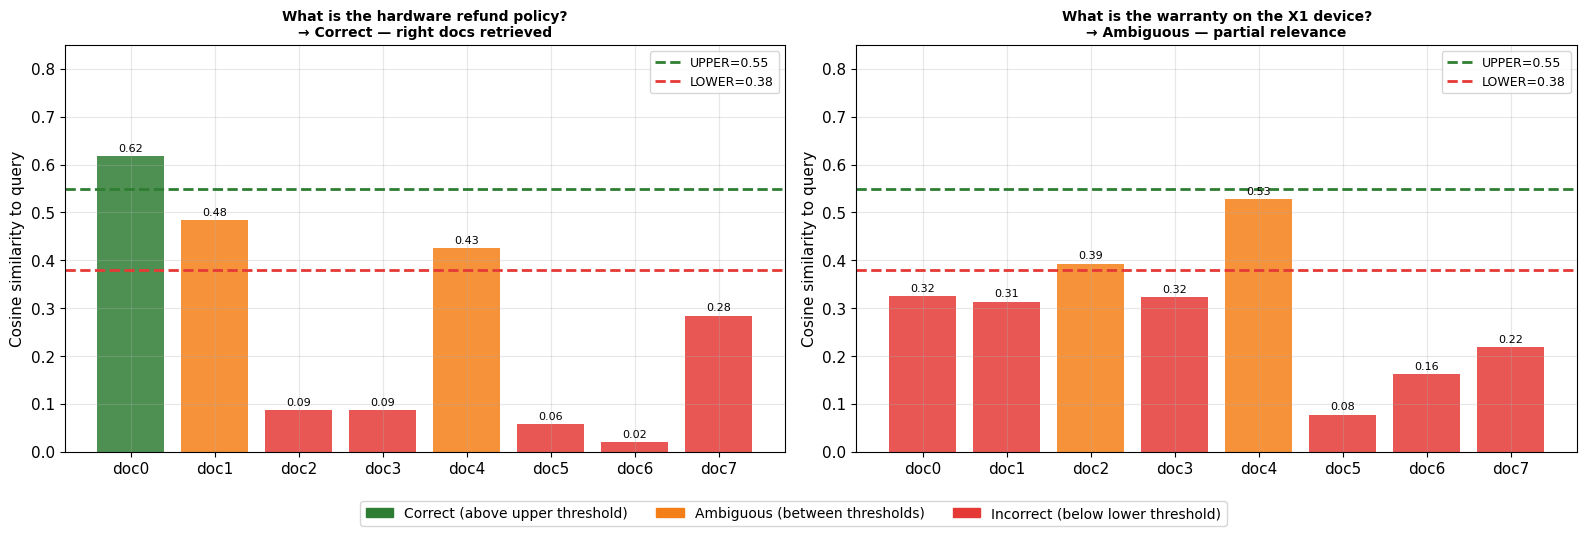

In [9]:
# Visualise: relevance score distribution across all corpus docs for two queries
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

queries_vis = [
    ('What is the hardware refund policy?',   'Correct — right docs retrieved'),
    ('What is the warranty on the X1 device?', 'Ambiguous — partial relevance'),
]

for ax, (q, label) in zip(axes, queries_vis):
    q_emb   = embedder.encode(q, convert_to_tensor=True, show_progress_bar=False)
    scores  = [float(util.cos_sim(q_emb, embedder.encode(d['text'], convert_to_tensor=True, show_progress_bar=False)))
               for d in CORPUS]
    doc_ids = [d['id'] for d in CORPUS]
    colors  = ['#2E7D32' if s > evaluator.UPPER else '#F57F17' if s > evaluator.LOWER else '#E53935'
               for s in scores]

    ax.bar(doc_ids, scores, color=colors, alpha=0.85)
    ax.axhline(evaluator.UPPER, color='#2E7D32', linewidth=2, linestyle='--', label=f'UPPER={evaluator.UPPER}')
    ax.axhline(evaluator.LOWER, color='#E53935', linewidth=2, linestyle='--', label=f'LOWER={evaluator.LOWER}')
    ax.set_ylim(0, 0.85)
    ax.set_ylabel('Cosine similarity to query')
    ax.set_title(f'{q}\n→ {label}', fontweight='bold', fontsize=10)
    ax.legend(fontsize=9)
    for i, (doc_id, score) in enumerate(zip(doc_ids, scores)):
        ax.text(i, score + 0.01, f'{score:.2f}', ha='center', fontsize=8)

legend_handles = [
    mpatches.Patch(color='#2E7D32', label='Correct (above upper threshold)'),
    mpatches.Patch(color='#F57F17', label='Ambiguous (between thresholds)'),
    mpatches.Patch(color='#E53935', label='Incorrect (below lower threshold)'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=3, fontsize=10, bbox_to_anchor=(0.5, -0.08))
show_plot()

---
## 4. Knowledge Refinement Strips

Even when retrieved docs are on the right topic, they contain noise — sentences unrelated to the specific question. CRAG-style knowledge refinement breaks each doc into sentences, scores each sentence individually, and keeps only the most relevant ones.

This is the difference between passing a 400-token paragraph to the LLM and passing the one 80-token sentence that actually answers the question.

In [10]:
def refine_strips(docs: list, query: str, top_n: int = 4) -> list:
    '''
    CRAG knowledge refinement:
    1. Split each doc into sentence strips
    2. Score each strip for relevance to the query
    3. Return the top_n strips as the refined context

    Returns list of (score, strip_text, source_doc_id) tuples, sorted descending.
    '''
    q_emb  = embedder.encode(query, convert_to_tensor=True, show_progress_bar=False)
    strips = []

    for doc in docs:
        # Split on '. ' to get individual sentences
        sentences = [s.strip() for s in doc['text'].split('. ') if len(s.strip()) > 20]
        for sent in sentences:
            if not sent.endswith('.'):
                sent = sent + '.'
            s_emb  = embedder.encode(sent, convert_to_tensor=True, show_progress_bar=False)
            score  = float(util.cos_sim(q_emb, s_emb))
            strips.append((score, sent, doc['id']))

    strips.sort(reverse=True)
    return strips[:top_n]


# Demo: warranty query — X1 specs doc retrieved but warranty doc also comes back
warranty_q    = 'What is the warranty period for the X1 device?'
warranty_docs = [d for d, _ in retrieve(warranty_q, top_k=4)]

print(f'Query: {warranty_q}')
print(f'Retrieved docs: {[d["id"] for d in warranty_docs]}')
print()
print('Full context (vanilla RAG passes all text to LLM):')
full_ctx = ' '.join(d['text'] for d in warranty_docs)
print(f'  {len(full_ctx.split())} words — includes specs, dimensions, GPU info...')
print()
print('Refined strips (CRAG passes only the most relevant sentences):')
refined = refine_strips(warranty_docs, warranty_q, top_n=3)
for score, strip, source in refined:
    print(f'  [{source}] score={score:.3f}  {strip}')
print()
print('The top strip comes from doc4 (warranty terms) — not the X1 specs doc.')
print('This is the sentence the LLM needs. Everything else is noise.')

Query: What is the warranty period for the X1 device?
Retrieved docs: ['doc4', 'doc2', 'doc0', 'doc1']

Full context (vanilla RAG passes all text to LLM):
  161 words — includes specs, dimensions, GPU info...

Refined strips (CRAG passes only the most relevant sentences):
  [doc4] score=0.486  All TechCo hardware products are covered by a standard one-year limited warranty.
  [doc4] score=0.459  The warranty covers manufacturing defects and component failures under normal use.
  [doc4] score=0.456  Extended warranty plans of two or three years are available for purchase separately.

The top strip comes from doc4 (warranty terms) — not the X1 specs doc.
This is the sentence the LLM needs. Everything else is noise.


---
## 5. Gate 3 — Self-Supported Check

After generating an answer, verify that the claims it makes are actually present in the context. Specific numbers (warranty years, prices, timeframes) are the most common source of hallucination — if a number appears in the answer but not in the context, the LLM invented it.

In [11]:
def is_supported(answer: str, context: str) -> tuple:
    '''
    Check whether the answer is grounded in the context.

    Checks:
      1. Warranty year claims (e.g. "3-year warranty") must match context
      2. Price claims (e.g. "$9.99") must appear in context
      3. Timeframe claims (e.g. "30 days") must appear in context

    Returns (supported: bool, reason: str).

    In production, use an LLM-as-judge:
      prompt = f"Is this answer fully supported by the context? YES/NO.\nContext: {context}\nAnswer: {answer}"
    '''
    ans = answer.lower()
    ctx = context.lower()

    # Check 1: warranty period claims
    warranty_ans = re.search(r'(\d+)\s*-?\s*year\s*warranty', ans)
    warranty_ctx = re.search(r'(\d+)\s*-?\s*year\s*(?:limited\s*)?warranty', ctx)
    if warranty_ans:
        ans_years = warranty_ans.group(1)
        if not warranty_ctx:
            return False, f'Answer claims a {ans_years}-year warranty, but context contains no warranty period'
        ctx_years = warranty_ctx.group(1)
        if ans_years != ctx_years:
            return False, f'Warranty mismatch: answer says {ans_years} years, context says {ctx_years} years'

    # Check 2: price claims
    prices_in_ans = re.findall(r'\$[\d,\.]+', answer)
    for price in prices_in_ans:
        if price.lower() not in ctx:
            return False, f'Price {price} appears in answer but not in context'

    # Check 3: day/timeframe claims
    timeframes_ans = re.findall(r'(\d+)\s*(?:business\s*)?days?', ans)
    timeframes_ctx = re.findall(r'(\d+)\s*(?:business\s*)?days?', ctx)
    for tf in timeframes_ans:
        if tf not in timeframes_ctx:
            return False, f'Timeframe of {tf} days in answer not found in context'

    return True, 'Answer appears grounded in context'


# Demo: hallucinated vs. grounded answer
print('=== Self-supported check demo ===')
print()
context_no_warranty = CORPUS[2]['text']  # X1 specs — no warranty info
context_with_warranty = CORPUS[4]['text']  # warranty terms — has one-year info

hallucinated = 'The TechCo X1 comes with a comprehensive 3-year warranty covering all hardware defects.'
grounded     = 'TechCo hardware products are covered by a one-year limited warranty for manufacturing defects.'

for answer, ctx, label in [
    (hallucinated, context_no_warranty,   'Hallucinated answer vs. X1 specs context'),
    (hallucinated, context_with_warranty, 'Hallucinated answer vs. warranty context'),
    (grounded,     context_with_warranty, 'Grounded answer vs. warranty context'),
]:
    supported, reason = is_supported(answer, ctx)
    mark = 'SUPPORTED' if supported else 'UNSUPPORTED'
    print(f'Scenario: {label}')
    print(f'  Answer:  {answer[:80]}')
    print(f'  Result:  {mark} — {reason}')
    print()

=== Self-supported check demo ===

Scenario: Hallucinated answer vs. X1 specs context
  Answer:  The TechCo X1 comes with a comprehensive 3-year warranty covering all hardware d
  Result:  UNSUPPORTED — Answer claims a 3-year warranty, but context contains no warranty period

Scenario: Hallucinated answer vs. warranty context
  Answer:  The TechCo X1 comes with a comprehensive 3-year warranty covering all hardware d
  Result:  UNSUPPORTED — Answer claims a 3-year warranty, but context contains no warranty period

Scenario: Grounded answer vs. warranty context
  Answer:  TechCo hardware products are covered by a one-year limited warranty for manufact
  Result:  SUPPORTED — Answer appears grounded in context



---
## 6. Full CRAG Pipeline

Corrective RAG combines all the pieces: a quality evaluator that routes to one of three confidence tracks, knowledge refinement for good docs, and a fallback for bad ones.

In [12]:
ABSTENTION = 'I do not have reliable information about this in my knowledge base.'


def crag_pipeline(query: str, top_k: int = 4, verbose: bool = True) -> dict:
    '''
    Full CRAG pipeline:
      Gate 1: Does this query need retrieval?
      Retrieve top_k docs
      Evaluate: correct / ambiguous / incorrect?
      Correct   → refine strips → generate → check support
      Ambiguous → use docs as-is → generate → check support
      Incorrect → abstain (or trigger web search in production)
    '''
    steps = []

    # ── Gate 1: should we retrieve? ───────────────────────────────────────────
    should_ret, nr_reason = needs_retrieval(query)
    if not should_ret:
        answer = llm.direct_answer(query)
        steps.append(('gate1', f'SKIP retrieval — {nr_reason}'))
        steps.append(('answer', answer))
        steps.append(('supported', True))
        if verbose:
            print(f'[G1-SKIP] {query}')
            print(f'  → {answer}')
        return {'answer': answer, 'track': 'direct', 'steps': steps, 'supported': True}

    steps.append(('gate1', 'RETRIEVE'))

    # ── Retrieve ──────────────────────────────────────────────────────────────
    docs_with_scores = retrieve(query, top_k=top_k)
    docs             = [d for d, _ in docs_with_scores]

    # ── Gate 2: evaluate relevance ────────────────────────────────────────────
    track, scored_docs = evaluator.evaluate(query, docs)
    max_score          = max(s for _, s in scored_docs)
    steps.append(('gate2', f'track={track}, max_score={max_score:.3f}'))

    if track == 'incorrect':
        answer = ABSTENTION
        steps.append(('fallback', 'Abstain — no relevant docs found'))
        if verbose:
            print(f'[G2-INCORRECT] {query}')
            print(f'  → {answer}')
        return {'answer': answer, 'track': 'incorrect', 'steps': steps, 'supported': True}

    if track == 'correct':
        # Refine to keep only the best sentence strips
        refined  = refine_strips(docs, query, top_n=3)
        context  = ' '.join(strip for _, strip, _ in refined)
        steps.append(('refine', f'{len(refined)} strips kept from {len(docs)} docs'))
    else:
        # Ambiguous: use full doc context
        context = ' '.join(d['text'] for d in docs)
        steps.append(('ambiguous', 'use full context'))

    # ── Generate ──────────────────────────────────────────────────────────────
    answer = llm.generate(query, context)
    steps.append(('generate', answer[:80]))

    # ── Gate 3: self-supported check ──────────────────────────────────────────
    supported, sup_reason = is_supported(answer, context)
    steps.append(('gate3', f'supported={supported} — {sup_reason}'))

    if not supported:
        answer = f'[Low confidence] {answer}'
        steps.append(('flag', 'flagged as low confidence'))

    if verbose:
        print(f'[{track.upper()}] {query}')
        for step, detail in steps:
            print(f'  [{step}] {detail}')

    return {'answer': answer, 'track': track, 'steps': steps, 'supported': supported}


print('crag_pipeline() ready.')

crag_pipeline() ready.


In [13]:
# Demo: all three tracks in action
crag_demos = [
    ('Hi, can you help me?',                    'Gate 1: skip retrieval'),
    ('What is the hardware refund policy?',      'Correct track: refine + generate'),
    ('What is the warranty on the X1 device?',  'Correct or Ambiguous: test support check'),
    ('What is the CEO compensation package?',   'Incorrect track: abstain'),
]

for q, label in crag_demos:
    print(f'=== {label} ===')
    result = crag_pipeline(q, verbose=True)
    print(f'Final answer: {result["answer"]}')
    print()

=== Gate 1: skip retrieval ===
[G1-SKIP] Hi, can you help me?
  → Hello! I am here to help with your TechCo product questions.
Final answer: Hello! I am here to help with your TechCo product questions.

=== Correct track: refine + generate ===
[CORRECT] What is the hardware refund policy?
  [gate1] RETRIEVE
  [gate2] track=correct, max_score=0.618
  [refine] 3 strips kept from 4 docs
  [generate] Hardware products can be returned within 30 days for a full refund.
  [gate3] supported=True — Answer appears grounded in context
Final answer: Hardware products can be returned within 30 days for a full refund.

=== Correct or Ambiguous: test support check ===
[AMBIGUOUS] What is the warranty on the X1 device?
  [gate1] RETRIEVE
  [gate2] track=ambiguous, max_score=0.528
  [ambiguous] use full context
  [generate] TechCo hardware products are covered by a one-year limited warranty for manufact
  [gate3] supported=True — Answer appears grounded in context
Final answer: TechCo hardware products

---
## 7. Self-RAG Concepts — The Reflection Token Approach

Self-RAG (Asai et al., 2023) takes the same insight as CRAG — the model should reason about its own retrieval — but implements it differently: a **fine-tuned model** emits special tokens during generation that act as control signals.

| Token | When emitted | Signal |
|---|---|---|
| `[Retrieve=Yes/No]` | Before any generation | Does this query need retrieval? |
| `[IsRel=Relevant/Irrelevant]` | After seeing each retrieved doc | Is this doc worth using? |
| `[IsSup=Fully/Partially/No]` | After generating a sentence | Is this sentence supported by the doc? |
| `[IsUse=1..5]` | After the full response | How useful was the overall response? |

The model is constantly checking itself — retrieval, relevance, and faithfulness all in one forward pass.

In [14]:
class MockSelfRAG:
    '''
    Illustrates the Self-RAG reflection token flow.
    In reality, this requires a fine-tuned model (original used LLaMA-2).
    This mock uses rule-based logic to show the CONCEPT, not the real system.
    '''

    def process(self, query: str, top_k: int = 3) -> list:
        q     = query.lower()
        steps = []

        # Token 1: Retrieve decision
        should_ret, _ = needs_retrieval(query)
        token_ret     = '[Retrieve=Yes]' if should_ret else '[Retrieve=No]'
        steps.append(('token', token_ret))

        if not should_ret:
            answer = llm.direct_answer(query)
            steps.append(('generate', answer))
            steps.append(('token', '[IsUse=5]'))
            return steps

        # Retrieve
        docs = retrieve(query, top_k=top_k)

        # Token 2: IsRel for each doc
        relevant_docs = []
        for doc, sim_score in docs:
            is_rel = sim_score > evaluator.LOWER
            token  = '[IsRel=Relevant]' if is_rel else '[IsRel=Irrelevant]'
            steps.append(('token', f'{token} ({doc["id"]}: {doc["title"]}, sim={sim_score:.3f})'))
            if is_rel:
                relevant_docs.append(doc)

        if not relevant_docs:
            steps.append(('generate', ABSTENTION))
            steps.append(('token', '[IsUse=1]'))
            return steps

        # Generate from relevant docs
        context  = ' '.join(d['text'] for d in relevant_docs)
        answer   = llm.generate(query, context)
        steps.append(('generate', answer))

        # Token 3: IsSup check
        supported, reason = is_supported(answer, context)
        token_sup = '[IsSup=Fully]' if supported else '[IsSup=Partially]'
        steps.append(('token', f'{token_sup} — {reason}'))

        # Token 4: IsUse rating
        use_rating = 5 if supported else 3
        steps.append(('token', f'[IsUse={use_rating}]'))

        return steps


self_rag = MockSelfRAG()

print('=== Self-RAG reflection token flow ===')
for q in ['Hi, can you help me?', 'What is the warranty on the X1 device?']:
    print(f'\nQuery: {q}')
    steps = self_rag.process(q)
    for kind, detail in steps:
        icon = '' if kind == 'token' else '  '
        print(f'  {icon}{detail}')

print()
print('Key difference from CRAG:')
print('  Self-RAG: reflection tokens baked INTO the model (requires fine-tuning)')
print('  CRAG:     quality gate ALONGSIDE the model (plug-and-play, any LLM)')

=== Self-RAG reflection token flow ===

Query: Hi, can you help me?
  [Retrieve=No]
    Hello! I am here to help with your TechCo product questions.
  [IsUse=5]

Query: What is the warranty on the X1 device?
  [Retrieve=Yes]
  [IsRel=Relevant] (doc4: Warranty Terms, sim=0.528)
  [IsRel=Relevant] (doc2: X1 Device Specifications, sim=0.393)
  [IsRel=Irrelevant] (doc0: Hardware Refund Policy, sim=0.324)
    TechCo hardware products are covered by a one-year limited warranty for manufacturing defects.
  [IsSup=Fully] — Answer appears grounded in context
  [IsUse=5]

Key difference from CRAG:
  Self-RAG: reflection tokens baked INTO the model (requires fine-tuning)
  CRAG:     quality gate ALONGSIDE the model (plug-and-play, any LLM)


---
## 8. Evaluation: Vanilla RAG vs. Adaptive RAG

Run 10 queries through both pipelines. Score each answer: 1.0 = correct, 0.5 = partial, 0.0 = wrong.

In [15]:
EVAL_SET = [
    # Queries that do NOT need retrieval
    {'query': 'Hi, can you help me?',
     'expected_contains': 'Hello',
     'expected_excludes': 'refund',
     'label': 'Greeting (no-retrieval)'},

    {'query': 'What is 2 + 2?',
     'expected_contains': '4',
     'expected_excludes': 'warranty',
     'label': 'Math (no-retrieval)'},

    {'query': 'Tell me a joke.',
     'expected_contains': 'dark mode',
     'expected_excludes': 'techco',
     'label': 'Creative (no-retrieval)'},

    # Queries that DO need retrieval — correct docs available
    {'query': 'What is the hardware refund policy?',
     'expected_contains': '30 days',
     'expected_excludes': 'software',
     'label': 'Hardware refund (correct docs)'},

    {'query': 'How much does standard shipping cost?',
     'expected_contains': '$9.99',
     'expected_excludes': 'warranty',
     'label': 'Shipping cost (correct docs)'},

    {'query': 'How do I install the TechCo device?',
     'expected_contains': 'Setup Assistant',
     'expected_excludes': 'refund',
     'label': 'Installation (correct docs)'},

    {'query': 'How is billing handled?',
     'expected_contains': 'monthly',
     'expected_excludes': 'warranty',
     'label': 'Billing (correct docs)'},

    # Warranty query — hallucination trap
    {'query': 'What is the warranty on the X1 device?',
     'expected_contains': 'one-year',
     'expected_excludes': '3-year',
     'label': 'Warranty X1 (hallucination trap)'},

    # Out-of-domain query — should abstain
    {'query': 'What is the CEO compensation package?',
     'expected_contains': 'not have',
     'expected_excludes': '30 days',
     'label': 'CEO pay (out-of-domain)'},

    # Wrong-docs scenario
    {'query': 'What is the hardware refund policy?',
     'expected_contains': '30 days',
     'expected_excludes': 'non-refundable',
     'label': 'Hardware refund (wrong-docs check)'},
]


def score_answer(answer: str, expected_contains: str, expected_excludes: str) -> float:
    a = answer.lower()
    has_correct = expected_contains.lower() in a
    has_wrong   = expected_excludes.lower() in a
    if has_correct and not has_wrong:
        return 1.0
    if has_correct and has_wrong:
        return 0.5
    return 0.0


vanilla_scores = []
crag_scores    = []

print(f'{"Label":<36} {"Vanilla":<10} {"CRAG":<10} {"Delta"}')
print('-' * 70)

for item in EVAL_SET:
    q    = item['query']
    inc  = item['expected_contains']
    exc  = item['expected_excludes']

    v_ans    = vanilla_rag(q)['answer']
    c_result = crag_pipeline(q, verbose=False)
    c_ans    = c_result['answer']

    v_score = score_answer(v_ans, inc, exc)
    c_score = score_answer(c_ans, inc, exc)

    vanilla_scores.append(v_score)
    crag_scores.append(c_score)

    delta = c_score - v_score
    sign  = '+' if delta > 0 else ('=' if delta == 0 else '-')
    print(f'{item["label"]:<36} {v_score:<10.1f} {c_score:<10.1f} {sign}{abs(delta):.1f}')

print()
print(f'Average score  Vanilla: {np.mean(vanilla_scores):.2f}  CRAG: {np.mean(crag_scores):.2f}')
print(f'Improvement:   +{np.mean(crag_scores) - np.mean(vanilla_scores):.2f} average score')

Label                                Vanilla    CRAG       Delta
----------------------------------------------------------------------
Greeting (no-retrieval)              0.5        1.0        +0.5
Math (no-retrieval)                  1.0        1.0        =0.0
Creative (no-retrieval)              0.0        1.0        +1.0
Hardware refund (correct docs)       1.0        1.0        =0.0
Shipping cost (correct docs)         1.0        1.0        =0.0
Installation (correct docs)          1.0        1.0        =0.0
Billing (correct docs)               1.0        1.0        =0.0
Warranty X1 (hallucination trap)     1.0        1.0        =0.0
CEO pay (out-of-domain)              0.0        1.0        +1.0
Hardware refund (wrong-docs check)   1.0        1.0        =0.0

Average score  Vanilla: 0.75  CRAG: 1.00
Improvement:   +0.25 average score


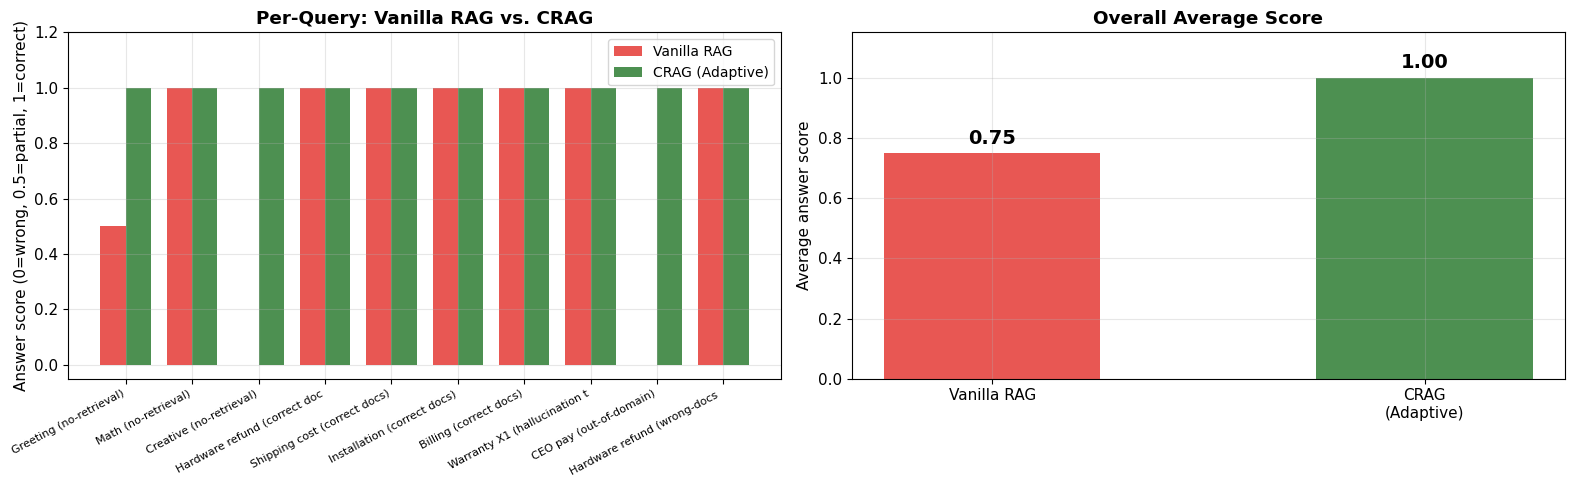

Where the improvement comes from:
  IMPROVED: Greeting (no-retrieval)  (0.5 → 1.0)
  IMPROVED: Creative (no-retrieval)  (0.0 → 1.0)
  IMPROVED: CEO pay (out-of-domain)  (0.0 → 1.0)


In [16]:
# Visualise the before / after comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

labels = [item['label'][:28] for item in EVAL_SET]
x      = np.arange(len(EVAL_SET))
width  = 0.38

# Left: per-query comparison
b_v = axes[0].bar(x - width/2, vanilla_scores, width, color='#E53935', alpha=0.85, label='Vanilla RAG')
b_c = axes[0].bar(x + width/2, crag_scores,    width, color='#2E7D32', alpha=0.85, label='CRAG (Adaptive)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=28, ha='right', fontsize=8)
axes[0].set_ylim(-0.05, 1.2)
axes[0].set_ylabel('Answer score (0=wrong, 0.5=partial, 1=correct)')
axes[0].set_title('Per-Query: Vanilla RAG vs. CRAG', fontweight='bold')
axes[0].legend(fontsize=10)

# Right: aggregate comparison
strategies = ['Vanilla RAG', 'CRAG\n(Adaptive)']
avgs       = [np.mean(vanilla_scores), np.mean(crag_scores)]
colors     = ['#E53935', '#2E7D32']

bars = axes[1].bar(strategies, avgs, color=colors, alpha=0.85, width=0.5)
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel('Average answer score')
axes[1].set_title('Overall Average Score', fontweight='bold')
for bar, val in zip(bars, avgs):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.03,
                 f'{val:.2f}', ha='center', fontsize=14, fontweight='bold')

show_plot()

# Failure mode breakdown
print('Where the improvement comes from:')
for i, item in enumerate(EVAL_SET):
    if vanilla_scores[i] < crag_scores[i]:
        print(f'  IMPROVED: {item["label"]}  ({vanilla_scores[i]:.1f} → {crag_scores[i]:.1f})')

---
## 9. Using a Real LLM (Claude API)

Replace all four mock gates with real Claude calls. The prompts are the same; Claude replaces the keyword rules and pattern matching.

Install: `pip install anthropic`  
Set key: `export ANTHROPIC_API_KEY=sk-ant-...`

In [ ]:
ANTHROPIC_AVAILABLE = False
try:
    import anthropic
    ANTHROPIC_AVAILABLE = bool(os.environ.get('ANTHROPIC_API_KEY'))
except ImportError:
    pass


GATE1_PROMPT = '''\
Does this question require looking up specific information from a product knowledge base
to answer accurately? Answer only YES or NO.

Question: {query}'''

GATE2_PROMPT = '''\
Is the following passage relevant to answering the question?
Answer only YES or NO.

Question: {query}
Passage: {passage}'''

GENERATE_PROMPT = '''\
Answer the question using ONLY the provided context.
If the context does not contain enough information, say so.

Context: {context}
Question: {query}
Answer:'''

GATE3_PROMPT = '''\
Is this answer fully supported by the context provided?
Answer only YES or NO.

Context: {context}
Answer: {answer}'''


if ANTHROPIC_AVAILABLE:
    client = anthropic.Anthropic()

    def ask_claude(prompt: str, max_tokens: int = 64) -> str:
        resp = client.messages.create(
            model='claude-haiku-4-5-20251001',
            max_tokens=max_tokens,
            messages=[{'role': 'user', 'content': prompt}],
        )
        return resp.content[0].text.strip()

    def claude_adaptive_rag(query: str, top_k: int = 3) -> dict:
        # Gate 1
        g1 = ask_claude(GATE1_PROMPT.format(query=query))
        if 'no' in g1.lower():
            answer = ask_claude(f'Answer this question concisely: {query}', max_tokens=256)
            return {'answer': answer, 'track': 'direct', 'gate1': g1}

        # Retrieve + Gate 2
        docs_raw      = retrieve(query, top_k=top_k)
        relevant_docs = []
        for doc, _ in docs_raw:
            g2 = ask_claude(GATE2_PROMPT.format(query=query, passage=doc['text'][:300]))
            if 'yes' in g2.lower():
                relevant_docs.append(doc)

        if not relevant_docs:
            return {'answer': ABSTENTION, 'track': 'incorrect'}

        # Refine + Generate
        refined  = refine_strips(relevant_docs, query, top_n=3)
        context  = ' '.join(strip for _, strip, _ in refined)
        answer   = ask_claude(GENERATE_PROMPT.format(context=context, query=query), max_tokens=300)

        # Gate 3
        g3 = ask_claude(GATE3_PROMPT.format(context=context, answer=answer))
        if 'no' in g3.lower():
            answer = f'[Low confidence] {answer}'

        return {'answer': answer, 'track': 'correct', 'supported': 'yes' in g3.lower()}

    # Run on the three failure mode queries
    test_qs = [
        'Hi, can you help me?',
        'What is the hardware refund policy?',
        'What is the warranty on the X1 device?',
    ]
    print('=== Claude Adaptive RAG ===')
    for q in test_qs:
        result = claude_adaptive_rag(q)
        print(f'Q: {q}')
        print(f'Track: {result["track"]}')
        print(f'A: {result["answer"]}')
        print()

else:
    print('anthropic not installed or ANTHROPIC_API_KEY not set.')
    print()
    print('To enable this section:')
    print('  pip install anthropic')
    print('  export ANTHROPIC_API_KEY=sk-ant-...')
    print()
    print('The four prompts above map to the four gates in the adaptive pipeline:')
    print('  GATE1_PROMPT  — needs_retrieval() classifier')
    print('  GATE2_PROMPT  — RelevanceEvaluator per document')
    print('  GENERATE_PROMPT — the main answer generation')
    print('  GATE3_PROMPT  — is_supported() self-check')
    print()
    print('Use claude-haiku-4-5-20251001 for all gates except generation.')
    print('Gates are simple YES/NO tasks — Haiku is fast and cheap enough.')
    print('For generation, upgrade to claude-sonnet-4-6 if answer quality matters.')

---
## Key Takeaways

1. **Vanilla RAG makes three bad assumptions.** It always retrieves (even when not needed), always trusts what it retrieves (even when wrong), and always generates (even when unsupported). Each assumption causes a distinct failure mode.

2. **Self-RAG bakes the decision logic into the model via reflection tokens.** The model emits `[Retrieve]`, `[IsRel]`, `[IsSup]`, and `[IsUse]` tokens during generation. Powerful in theory, but requires fine-tuning — not practical for most production teams.

3. **CRAG makes the same insight plug-and-play.** Add a relevance evaluator between retrieval and generation. Route to three tracks: Correct (refine and use), Incorrect (fallback), Ambiguous (hedge). Works with any LLM, no fine-tuning required.

4. **Knowledge refinement strips are the most underrated improvement.** Breaking docs into sentences and scoring each individually is cheap, fast, and removes noise that causes hallucination. It is CRAG's most transferable idea.

5. **Four practical checks you can steal today:**
   - Gate 1: `needs_retrieval(query)` — skip the vector DB for greetings and math
   - Gate 2: `evaluator.evaluate(query, docs)` — score docs before passing to LLM
   - Refinement: `refine_strips(docs, query)` — keep only the most relevant sentences
   - Gate 3: `is_supported(answer, context)` — flag answers that contain invented claims

6. **The decision layer is the contribution.** Whether it lives inside the LLM (Self-RAG) or alongside it (CRAG) is an implementation detail. The key shift is from treating RAG as a pipeline to treating it as a decision graph: *when should I trust my retriever, and what do I do when I should not?*

7. **These checks add latency and cost.** Gate 2 runs one evaluator call per retrieved doc. Gate 3 runs a support check after generation. For latency-sensitive apps, apply selectively — run the checks on query types that tend to fail, skip them where the pipeline is reliable.

---

*Up next: Lesson 8.7 — Iterative and agentic retrieval: when a question is so complex that even adaptive single-step retrieval is not enough, and the system needs to plan its way to an answer across multiple rounds of retrieval, each round informed by what the previous one found.*